# 注意力汇聚：Nadaraya-Watson 核回归
本节将介绍注意力汇聚的更多细节， 以便从宏观上了解注意力机制在实践中的运作方式。

In [1]:
import torch
from torch import nn

生成数据集

回归问题：
给定的成对的“输入－输出”数据集
$\{(x_1, y_1), \ldots, (x_n, y_n)\}$，
如何学习$f$来预测任意新输入$x$的输出$\hat{y} = f(x)$？

根据下面的非线性函数生成一个人工数据集，
其中加入的噪声项为$\epsilon$：

$$y_i = 2\sin(x_i) + x_i^{0.8} + \epsilon,$$

其中$\epsilon$服从均值为$0$和标准差为$0.5$的正态分布。

In [2]:
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # 排序后的训练样本

In [3]:
def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
n_test

50

绘制训练样本，不带噪声项的真实数据生成函数 f （标记为“Truth”）， 以及学习得到的预测函数（标记为“Pred”）。

In [4]:
import matplotlib.pyplot as plt

def plot_kernel_reg(y_hat):
    plt.plot(x_test.detach().numpy(), y_truth.detach().numpy(), label='Truth')
    plt.plot(x_test.detach().numpy(), y_hat.detach().numpy(), label='Pred')
    plt.plot(x_train.detach().numpy(), y_train.detach().numpy(), 'o', alpha=0.5, label='Training Data')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(0, 5)
    plt.ylim(-1, 5)
    plt.legend()
    plt.show()

平均汇聚

基于平均汇聚来计算所有训练样本输出值的平均值：

$$f(x) = \frac{1}{n}\sum_{i=1}^n y_i,$$


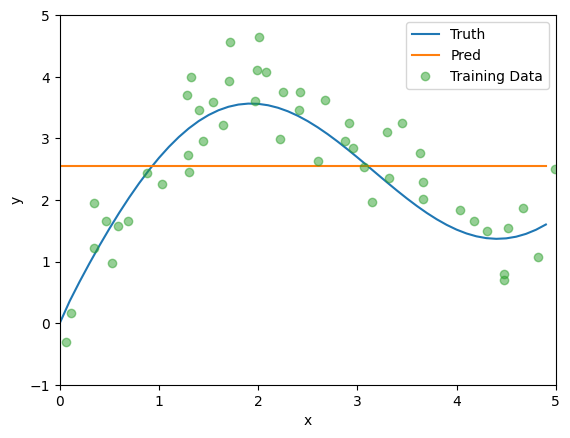

In [5]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

可见效果不好，真实函数 f （“Truth”）和预测函数（“Pred”）相差很大。

## 非参数注意力汇聚：Nadaraya-Watson 核回归

平均汇聚忽略了输入 $x_i$，为了更好地利用输入信息，Nadaraya 和 Watson 提出了根据输入位置对输出 $y_i$ 进行加权的方法，即 Nadaraya-Watson 核回归：

$$f(x) = \sum_{i=1}^n \frac{K(x - x_i)}{\sum_{j=1}^n K(x - x_j)} y_i$$

其中 $K$ 是核函数。这个公式可以推广为一个更通用的注意力汇聚公式：

$$f(x) = \sum_{i=1}^n \alpha(x, x_i) y_i$$

在这里，$x$ 是查询，$(x_i, y_i)$ 是键值对，$\alpha(x, x_i)$ 是注意力权重。注意力汇聚是 $y_i$ 的加权平均，注意力权重 $\alpha(x, x_i)$ 建模了查询 $x$ 和键 $x_i$ 之间的关系。这些权重是非负的且总和为1，形成一个有效的概率分布。

为了更好地理解，考虑一个高斯核，其定义为：

$$K(u) = \frac{1}{\sqrt{2\pi}} \exp(-\frac{u^2}{2})$$

将高斯核代入 Nadaraya-Watson 核回归和注意力汇聚公式，可以得到：

$$\begin{aligned} f(x) &= \sum_{i=1}^n \alpha(x, x_i) y_i\\ &= \sum_{i=1}^n \frac{\exp\left(-\frac{1}{2}(x - x_i)^2\right)}{\sum_{j=1}^n \exp\left(-\frac{1}{2}(x - x_j)^2\right)} y_i \\&= \sum_{i=1}^n \mathrm{softmax}\left(-\frac{1}{2}(x - x_i)^2\right) y_i \end{aligned}$$

这个公式表明，如果一个键 $x_i$ 越接近给定的查询 $x$，那么分配给这个键对应值 $y_i$ 的注意力权重就会越大，从而“获得更多的注意力”。

Nadaraya-Watson 核回归是一个非参数模型，因此上述模型被称为非参数的注意力汇聚模型。与平均汇聚相比，基于此模型绘制的预测结果通常会更平滑，并且更接近真实值。

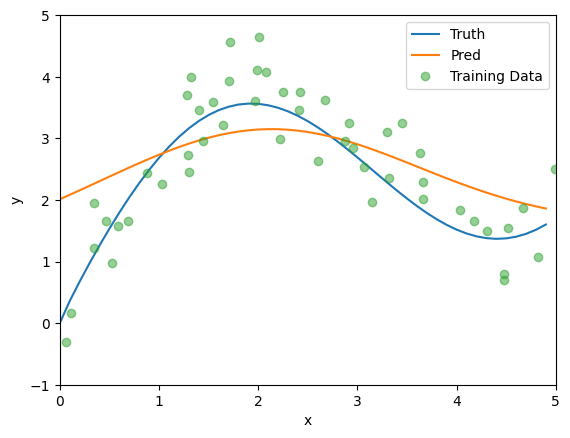

In [6]:
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# x_train包含着键。attention_weights的形状：(n_test,n_train),
# 每一行都包含着要在给定的每个查询的值（y_train）之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

观察注意力的权重。 这里测试数据的输入相当于查询，而训练数据的输入相当于键。观察可知“查询-键”对越接近， 注意力汇聚的注意力权重就越高。

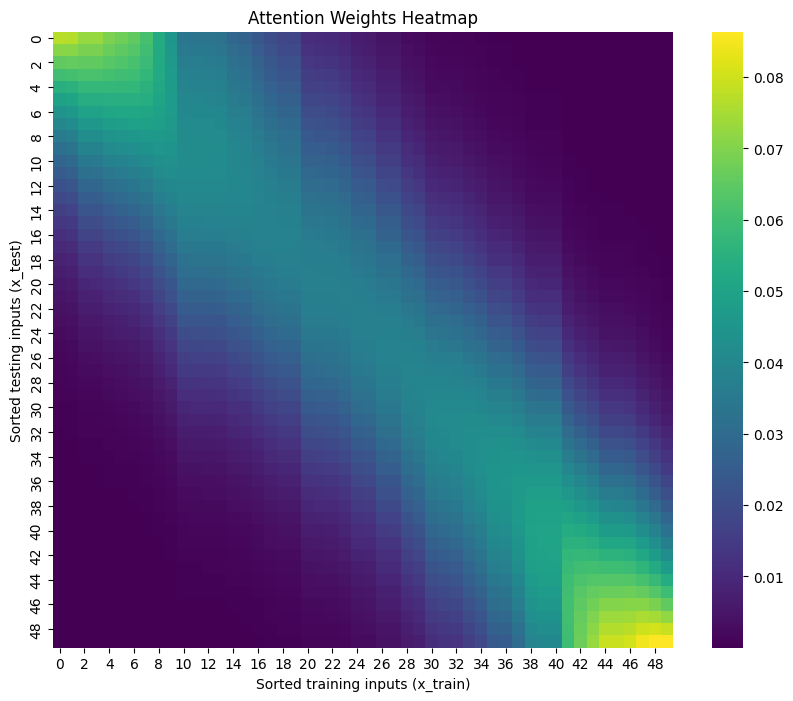

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(attention_weights.detach().numpy(), cmap='viridis')
plt.xlabel('Sorted training inputs (x_train)')
plt.ylabel('Sorted testing inputs (x_test)')
plt.title('Attention Weights Heatmap')
plt.show()

## 带参数注意力汇聚

尽管非参数的Nadaraya-Watson核回归在数据充足时能收敛到最优结果，我们仍然可以将可学习的参数整合到注意力汇聚中。

例如，通过在查询 $x$ 和键 $x_i$ 之间的距离上乘以一个可学习参数 $w$，我们可以得到以下形式：

$$\begin{aligned}f(x) &= \sum_{i=1}^n \alpha(x, x_i) y_i \\&= \sum_{i=1}^n \frac{\exp\left(-\frac{1}{2}((x - x_i)w)^2\right)}{\sum_{j=1}^n \exp\left(-\frac{1}{2}((x - x_j)w)^2\right)} y_i \\&= \sum_{i=1}^n \mathrm{softmax}\left(-\frac{1}{2}((x - x_i)w)^2\right) y_i.\end{aligned}$$

本节的后续部分将通过训练这个模型来学习注意力汇聚的参数。

### 批量矩阵乘法

为了更有效地计算小批量数据的注意力，可以利用深度学习框架中提供的批量矩阵乘法功能。

假设第一个小批量数据包含 $n$ 个形状为 $a \times b$ 的矩阵 $\mathbf{X}_1, \ldots, \mathbf{X}_n$，第二个小批量数据包含 $n$ 个形状为 $b \times c$ 的矩阵 $\mathbf{Y}_1, \ldots, \mathbf{Y}_n$。它们的批量矩阵乘法将得到 $n$ 个形状为 $a \times c$ 的矩阵 $\mathbf{X}_1\mathbf{Y}_1, \ldots, \mathbf{X}_n\mathbf{Y}_n$。因此，如果两个张量的形状分别是 $(n, a, b)$ 和 $(n, b, c)$，它们的批量矩阵乘法输出的形状将是 $(n, a, c)$。

In [9]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

使用小批量矩阵乘法来计算小批量数据中的加权平均值

In [10]:
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

定义模型

使用小批量矩阵乘法， 定义Nadaraya-Watson核回归的带参数版本为

In [11]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数，“键－值”对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        # values的形状为(查询个数，“键－值”对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

训练

将训练数据集变换为键和值来训练模型。



In [12]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))
# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

训练时，使用平方损失函数和随机梯度下降

epoch 1, loss 65.901260
epoch 2, loss 65.910179
epoch 3, loss 35.863445
epoch 4, loss 18.843336
epoch 5, loss 18.835262


/tmp/ipykernel_6497/770085316.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current_loss = float(l_sum)


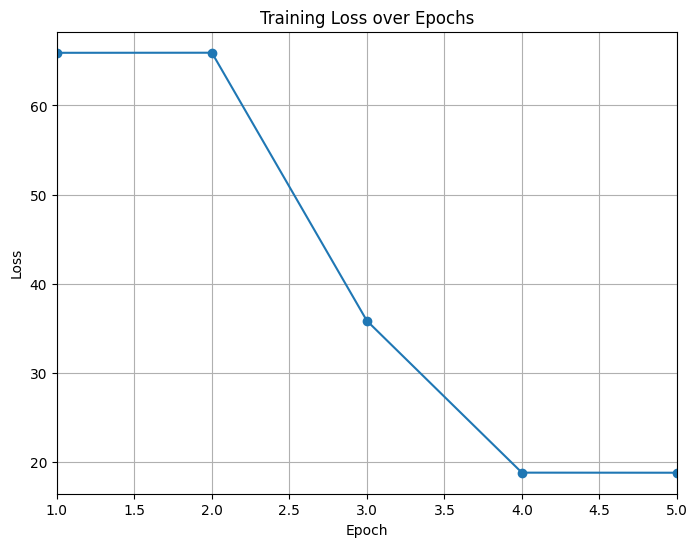

In [14]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)

# Initialize a list to store loss values for plotting
epoch_losses = []

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l_sum = l.sum()
    l_sum.backward()
    trainer.step()

    current_loss = float(l_sum)
    epoch_losses.append(current_loss)
    print(f'epoch {epoch + 1}, loss {current_loss:.6f}')

# Plotting the loss after training using matplotlib
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.xlim(1, 5)
plt.grid(True)
plt.show()

拟合带噪声的训练数据

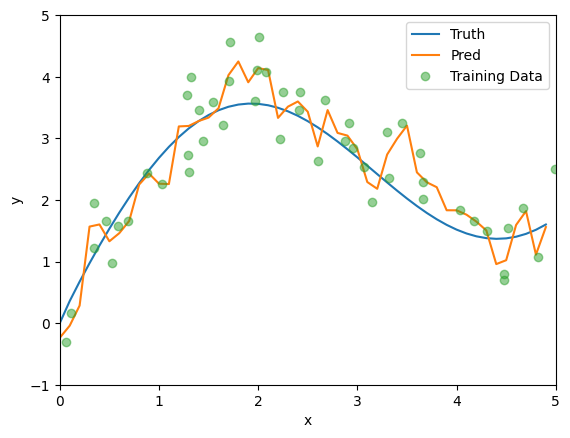

In [15]:
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
# value的形状:(n_test，n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

曲线在注意力权重较大的区域变得更不平滑